<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan11_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 11 - Unsupervised Learning (Clustering): K-Means, Hierarchical Clustering, Metode Elbow

# Segmentasi Pelanggan

Nama : Yusep Tiana

NIM : 250401020103

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('ggplot')

In [ ]:
np.random.seed(42)

# Kelompok pelanggan hemat
grp1 = np.random.normal([30,20],[6,8],(100,2))

# Kelompok pelanggan menengah
grp2 = np.random.normal([70,55],[8,10],(100,2))

# Kelompok pelanggan premium
grp3 = np.random.normal([110,85],[10,8],(100,2))

data = np.vstack([grp1,grp2,grp3])

df = pd.DataFrame(data,
                  columns=['pendapatan_tahunan',
                           'skor_belanja'])

df['usia'] = np.random.randint(18,65,len(df))
df['gender'] = np.random.choice(['L','P'],len(df))

df.head()

,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


(300, 4)


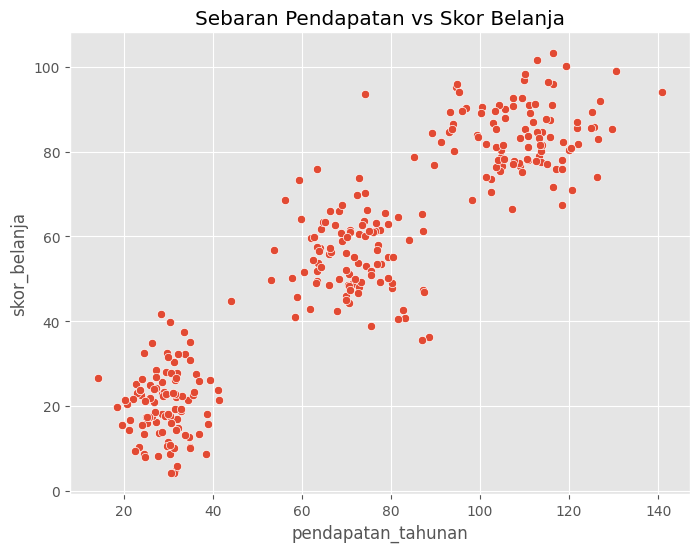

In [ ]:
print(df.shape)

df.describe()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja'
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

In [ ]:
X = df[['pendapatan_tahunan','skor_belanja']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Mean :",X_scaled.mean(axis=0))
print("Std  :",X_scaled.std(axis=0))

Mean : [-2.88657986e-17  7.92699240e-16]
Std  : [1. 1.]


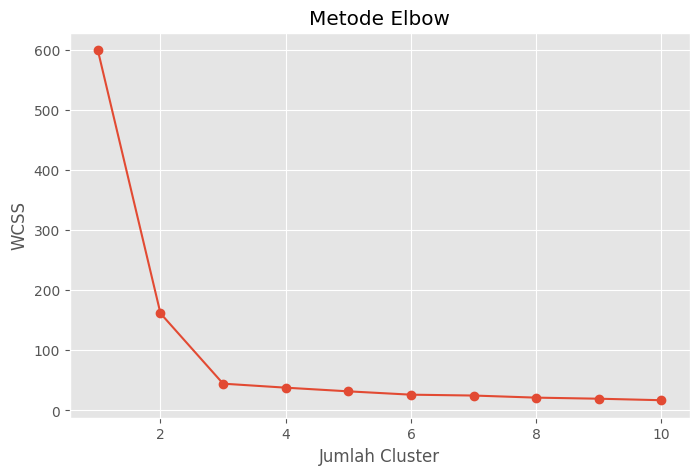

In [ ]:
wcss=[]

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Metode Elbow")

plt.show()

In [ ]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)

df['cluster'] = model.labels_

print("WCSS :",model.inertia_)

print("Silhouette Score :",
      silhouette_score(
          X_scaled,
          model.labels_
      ))

df.groupby("cluster")[[
    "pendapatan_tahunan",
    "skor_belanja"
]].mean()

WCSS : 44.5564179805733
Silhouette Score : 0.6953274658286891


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.994733,55.050104
1,29.306614,20.272179
2,109.198842,84.084249


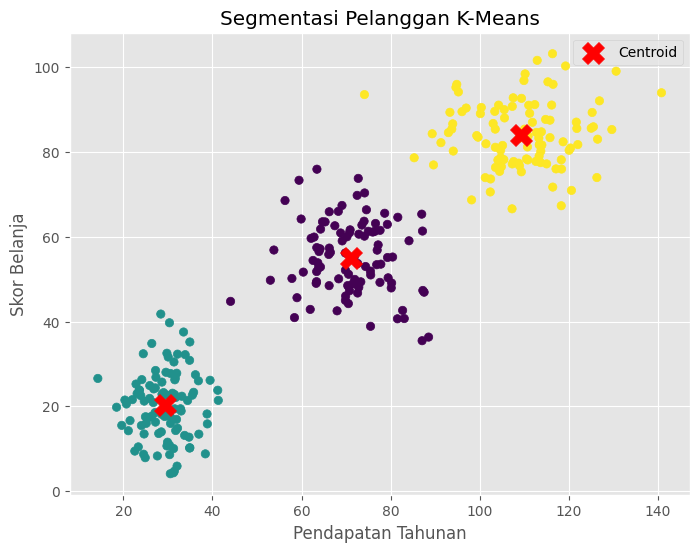

In [ ]:
centroids = scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=250,
    marker='X',
    label='Centroid'
)

plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan K-Means")
plt.legend()

plt.show()

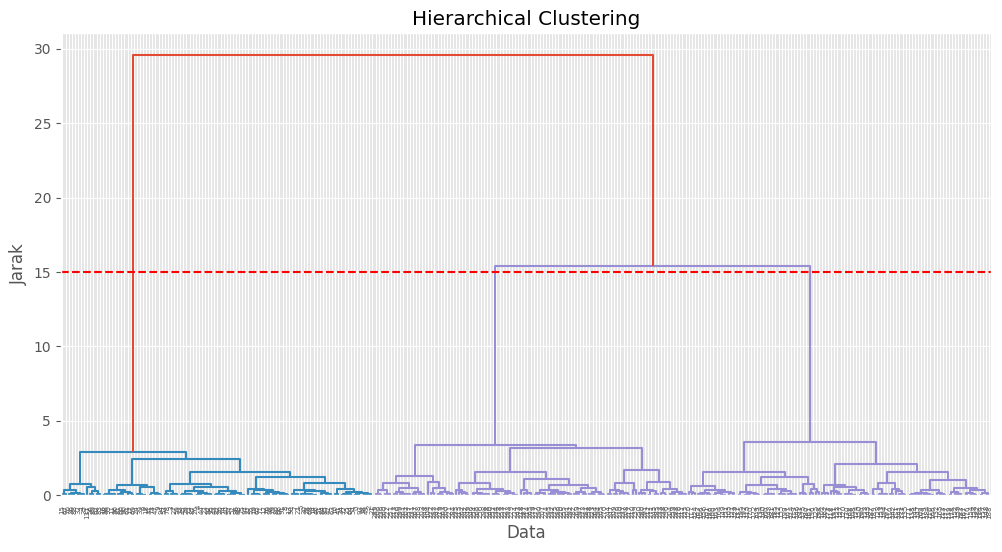

In [ ]:
Z = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.axhline(
    y=15,
    color='red',
    linestyle='--'
)

plt.title("Hierarchical Clustering")
plt.xlabel("Data")
plt.ylabel("Jarak")

plt.show()

# Kesimpulan
Berdasarkan hasil praktikum segmentasi pelanggan menggunakan algoritma K-Means, diperoleh bahwa jumlah cluster yang paling optimal adalah 3, sesuai dengan hasil pengamatan menggunakan Metode Elbow. Setelah dilakukan proses preprocessing menggunakan StandardScaler, model K-Means mampu mengelompokkan pelanggan ke dalam tiga segmen utama berdasarkan kemiripan pendapatan tahunan dan skor belanja, yaitu pelanggan dengan karakteristik hemat, menengah, dan premium. Hasil evaluasi menggunakan Silhouette Score menunjukkan kualitas clustering yang baik, sehingga pengelompokan yang dihasilkan dapat merepresentasikan pola data secara efektif. Selain itu, penerapan Hierarchical Clustering dengan metode Ward Linkage menghasilkan struktur pengelompokan yang konsisten dengan K-Means, sehingga memperkuat bahwa tiga cluster merupakan jumlah yang paling sesuai untuk dataset yang digunakan. Dengan demikian, algoritma clustering dapat dimanfaatkan sebagai metode yang efektif untuk melakukan segmentasi pelanggan dan mendukung pengambilan keputusan dalam strategi pemasaran maupun analisis perilaku pelanggan.